In [1]:
from sympy import false
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import pydicom
from pydose_rt import DoseEngine
from pydose_rt.data import MachineConfig, Phantom, loaders, Beam
from pydose_rt.utils.utils import sample_tensor_nearest
from pydose_rt.physics.fluence.fluence_modeling import compute_profile_ratios, create_radial_correction_map

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype=torch.float32

do_plot = True

measurements = loaders.load_asc_measurements("/home/bolo/Documents/PyDoseRT/test_data/10 MV Photons/TrueBeam X10 Squares OK.asc", coord_map=("X", "Z", "Y"))
field_size = 300

measurements = [measurement for measurement in measurements if measurement["header_dict"]["FSZ"] == [str(field_size), str(field_size)]]
measurements = [measurement for measurement in measurements if measurement["header_dict"]["EDS"][2] == measurement["header_dict"]["STS"][2]]
measurements = [measurement for measurement in measurements if (float(measurement["header_dict"]["STS"][2]) == 100.0) and (float(measurement["header_dict"]["EDS"][2]) == 100.0)]

In [2]:
resolution = (1.0, 1.0, 1.0)
ct_array_shape = (500, 500, 500)
phantom = Phantom.from_uniform_water(shape=ct_array_shape, spacing=resolution).to(device).to(dtype)
number_of_beams=1
starting_angle=0
iso_center=(0.0, 149.5, 0.0)
kernel_size=1001
beam = Beam.create(
    gantry_angle_deg=0.0, 
    number_of_leaf_pairs=60, 
    collimator_angle_deg=0.0, 
    field_size_mm=(field_size, field_size),
    iso_center=iso_center, 
    device=device, 
    dtype=dtype)

In [3]:

machine_config = MachineConfig(
    preset="../src/pydose_rt/data/machine_presets/umea_10MV.json",
    profile_corrections=None
    )
dose_engine = DoseEngine(
    machine_config, 
    kernel_size,
    phantom._resolution,
    image_template=phantom.density_image,
    beam_template=beam,
    device=device,
    dtype=dtype,
    adjust_values=False
)

dose = dose_engine.compute_dose(
    beam,
    ct_image=phantom.density_image).detach()
dose = dose


In [4]:
data = []

for i, measurement in enumerate(measurements):
    samples = sample_tensor_nearest(dose[0, ...], resolution, iso_center, measurement["coords_engine"])
    samples = samples * measurement["dose"].max() / samples.max()
    mape = np.mean(np.abs(samples - measurement["dose"])[measurement["dose"] > 0] /  measurement["dose"][measurement["dose"] > 0])
    thr_20 = 0.2 * measurement["dose"].max()
    thr_80 = 0.8 * measurement["dose"].max()
    penumbra_pred = sum((samples > thr_20) * (samples < thr_80))
    penumbra_measurement = sum((measurement["dose"] > thr_20) * (measurement["dose"] < thr_80))

    coords = measurement["coords_engine"]  # shape (N, 3) presumably

    # Indices of coordinates that actually change
    var_mask = np.var(coords, axis=0) != 0
    changing_idx = np.where(var_mask)[0]

    if changing_idx.size == 0:
        raise ValueError("No changing coordinates found in coords_engine.")

    # Compute physical distance along the line (only over changing components)
    # This works for 1D, 2D (diagonal), or 3D profiles
    diffs = np.diff(coords[:, changing_idx], axis=0)              # (N-1, k)
    seg_len = np.linalg.norm(diffs, axis=1)                       # (N-1,)
    dist = np.concatenate(([0.0], np.cumsum(seg_len)))            # (N,)
    ticks = dist - np.mean(dist)                                  # center at 0
    data.append((ticks[386::2], samples[386::2], measurement["dose"][386::2]))



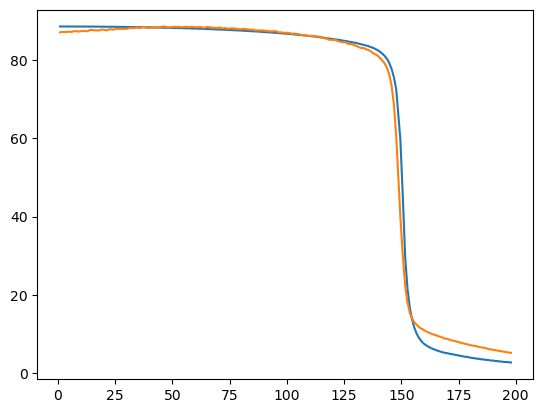

In [5]:
plt.plot(data[0][0], data[0][1])
plt.plot(data[0][0], data[0][2])

In [6]:
data[0][0][140]

141.6

In [7]:

# Stage 1: Compute sampled ratios
sample_points = np.linspace(0, 140, 15, endpoint=True)  # [0, 10, 20, ..., 500]
distances, ratios = compute_profile_ratios(
    data[0][2], data[0][1], data[0][0], sample_points
)

print(f"Sampled {len(ratios)} points")
print(f"Sample distances: {distances[:5]}... {distances[-5:]}")
print(f"Sample ratios: {ratios[:5]}... {ratios[-5:]}")


Sampled 15 points
Sample distances: [ 0. 10. 20. 30. 40.]... [100. 110. 120. 130. 140.]
Sample ratios: [0.98058732 0.9865708  0.99151836 0.99448646 0.99905838]... [1.0030059  1.00029372 0.99748954 0.9916116  0.98238697]


In [8]:
distances

array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140.])

In [9]:
ratios

array([0.98058732, 0.9865708 , 0.99151836, 0.99448646, 0.99905838,
       1.0027661 , 1.0040083 , 1.00493504, 1.00372523, 1.0037745 ,
       1.0030059 , 1.00029372, 0.99748954, 0.9916116 , 0.98238697])

In [10]:
np.stack([distances, ratios], 0)

array([[  0.        ,  10.        ,  20.        ,  30.        ,
         40.        ,  50.        ,  60.        ,  70.        ,
         80.        ,  90.        , 100.        , 110.        ,
        120.        , 130.        , 140.        ],
       [  0.98058732,   0.9865708 ,   0.99151836,   0.99448646,
          0.99905838,   1.0027661 ,   1.0040083 ,   1.00493504,
          1.00372523,   1.0037745 ,   1.0030059 ,   1.00029372,
          0.99748954,   0.9916116 ,   0.98238697]])

In [11]:

# Stage 2: Create correction map
image_shape = (386, 386)  # height, width
pixel_size = 1.0  # 1 mm per pixel
    
correction_map = create_radial_correction_map(
    distances,
    ratios,
    image_shape,
    pixel_size,
).cpu().detach().numpy()

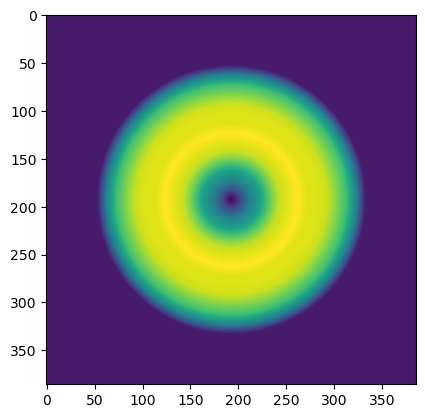

In [12]:
plt.imshow(correction_map)

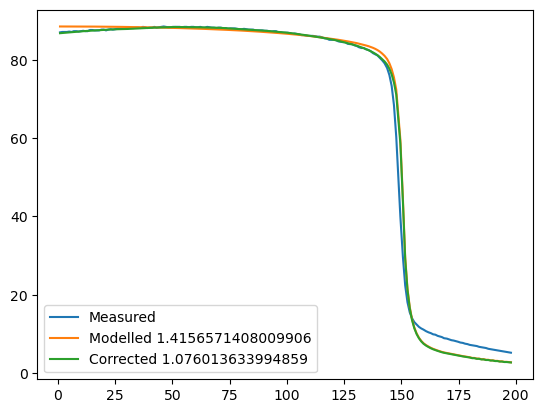

: 

In [ ]:
plt.plot(data[0][0], data[0][2], label="Measured")
plt.plot(data[0][0], data[0][1], label=f"Modelled {np.mean(np.abs(data[0][2] - data[0][1]))}")
plt.plot(data[0][0], correction_map[193:, 193] * data[0][1], label=f"Corrected {np.mean(np.abs(data[0][2] - correction_map[193:, 193] * data[0][1]))}")
plt.legend(loc="lower left")